### Why activation functions matter

In a neural network, each layer computes `z = W·x + b` and then passes `z` through an
**activation function** `f(z)` before sending it to the next layer. Without a non-linear
activation function, stacking layers would collapse into a single linear transformation,
no matter how many layers you add. Non-linear activations let a network approximate
complex, non-linear functions and are differentiable so that **back-propagation**
(gradient-based learning) can update the weights.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True


## 1. Sigmoid (Logistic) Activation Function

### Formula
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### Derivative
$$
\sigma'(z) = \sigma(z)\,\big(1 - \sigma(z)\big)
$$

### Mathematical properties
| Property | Value |
|---|---|
| Range | $(0, 1)$ |
| Domain | $(-\infty, \infty)$ |
| Monotonic | Yes (strictly increasing) |
| Zero-centered | **No** — output always positive |
| Shape | 'S'-shaped (sigmoidal) curve |
| Continuity | Continuously differentiable everywhere |
| Saturation | Saturates (flattens, derivative → 0) for large $\lvert z\rvert$ |
| Max derivative | $\sigma'(0) = 0.25$ |

### Advantages
- Smooth, continuously differentiable — easy to compute gradients everywhere.
- Output is bounded in $(0,1)$, so it can be interpreted as a **probability**, making it a natural choice for binary classification output layers.
- Simple, intuitive, historically the default choice for early neural networks.

### Disadvantages
- **Vanishing gradients**: for large positive or negative $z$, $\sigma'(z) \to 0$, so gradients become tiny and learning in deep hidden layers stalls.
- **Not zero-centered**: outputs are always in $(0,1)$, which makes gradient updates during optimization zig-zag / move consistently in one direction, slowing convergence.
- Computationally more expensive than ReLU because of the exponential.


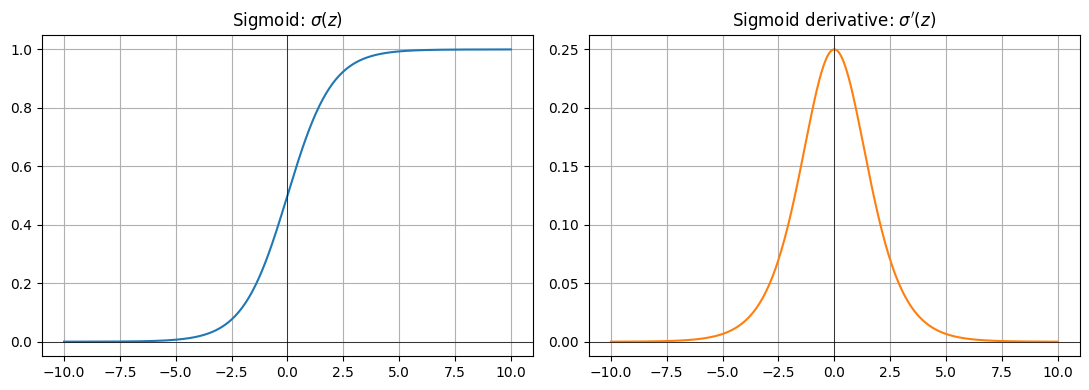

In [2]:
def sigmoid(z):
    return 1.0 / (1 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)

z = np.linspace(-10, 10, 400)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, sigmoid(z), color="tab:blue")
ax[0].set_title("Sigmoid: $\\sigma(z)$")
ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="k", lw=0.5)

ax[1].plot(z, sigmoid_prime(z), color="tab:orange")
ax[1].set_title("Sigmoid derivative: $\\sigma'(z)$")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()


## 2. Tanh (Hyperbolic Tangent)

### Formula
$$
\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}} = 2\,\sigma(2z) - 1
$$

### Derivative
$$
\tanh'(z) = 1 - \tanh^2(z)
$$

### Mathematical properties
| Property | Value |
|---|---|
| Range | $(-1, 1)$ |
| Domain | $(-\infty, \infty)$ |
| Monotonic | Yes (strictly increasing) |
| Zero-centered | **Yes** |
| Shape | 'S'-shaped, steeper than sigmoid near 0 |
| Symmetry | Odd function: $\tanh(-z) = -\tanh(z)$ |
| Max derivative | $\tanh'(0) = 1$ |

### Advantages
- **Zero-centered output** $(-1, 1)$ — fixes sigmoid's non-zero-centered problem, so gradient updates during optimization are more balanced and convergence is generally faster.
- Stronger gradients near zero than sigmoid (derivative up to 1 vs 0.25), which can speed up learning.
- Still smooth and differentiable everywhere.

### Disadvantages
- **Still suffers from vanishing gradients** at the extremes — for large $\lvert z\rvert$, $\tanh'(z) \to 0$, just as with sigmoid.
- More computationally expensive than ReLU (exponentials involved).
- Like sigmoid, saturates and can slow/stall training in very deep networks.


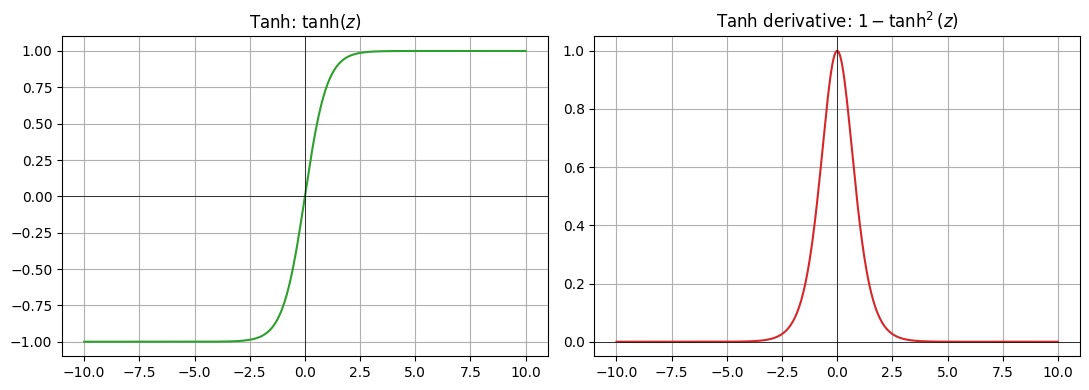

In [3]:
def tanh(z):
    return (np.exp(z) - np.exp(-z)) / (np.exp(z) + np.exp(-z))

def tanh_prime(z):
    return 1 - np.power(tanh(z), 2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, tanh(z), color="tab:green")
ax[0].set_title("Tanh: $\\tanh(z)$")
ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="k", lw=0.5)

ax[1].plot(z, tanh_prime(z), color="tab:red")
ax[1].set_title("Tanh derivative: $1 - \\tanh^2(z)$")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()


### Sigmoid vs Tanh

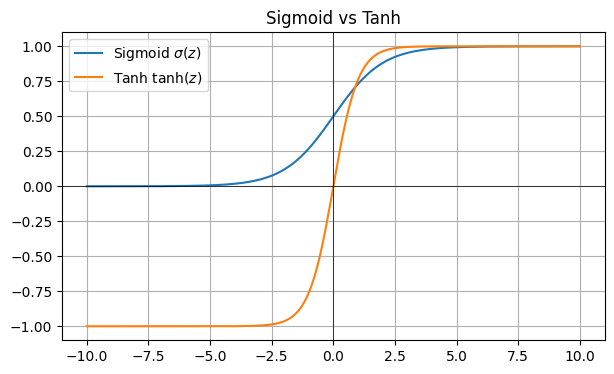

In [4]:
plt.plot(z, sigmoid(z), label="Sigmoid $\\sigma(z)$")
plt.plot(z, tanh(z), label="Tanh $\\tanh(z)$")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.title("Sigmoid vs Tanh")
plt.legend()
plt.show()


## 3. ReLU (Rectified Linear Unit)

### Formula
$$
\text{ReLU}(z) = \max(0, z)
$$

### Derivative
$$
\text{ReLU}'(z) =
\begin{cases}
1, & z > 0 \\
0, & z < 0 \\
\text{undefined (commonly set to 0 or 1)}, & z = 0
\end{cases}
$$

### Mathematical properties
| Property | Value |
|---|---|
| Range | $[0, \infty)$ |
| Domain | $(-\infty, \infty)$ |
| Monotonic | Yes (non-decreasing) |
| Zero-centered | No |
| Linear/Non-linear | Piecewise-linear, but **non-linear overall** (the "kink" at 0 is what makes it non-linear) |
| Differentiability | Not differentiable at $z=0$ (sub-gradient used in practice) |
| Sparsity | Produces exact zeros for $z \le 0$ → sparse activations |

### Advantages
- **Avoids vanishing gradients** for $z>0$ since the gradient is a constant 1, so it doesn't shrink as it propagates through many layers.
- **Computationally cheap** — just a max/threshold operation, no exponentials, so training and inference are faster than sigmoid/tanh.
- Induces **sparsity**: many neurons output exactly 0, which can make representations more efficient.
- Empirically, the most widely used activation in **hidden layers** of deep networks.

### Disadvantages
- **Dying ReLU problem**: for $z<0$ the gradient is exactly 0, so weights feeding a permanently-negative activation never update again — the neuron "dies" and stops responding to any input.
- Not zero-centered.
- Unbounded output can occasionally lead to exploding activations without proper weight initialization/normalization.


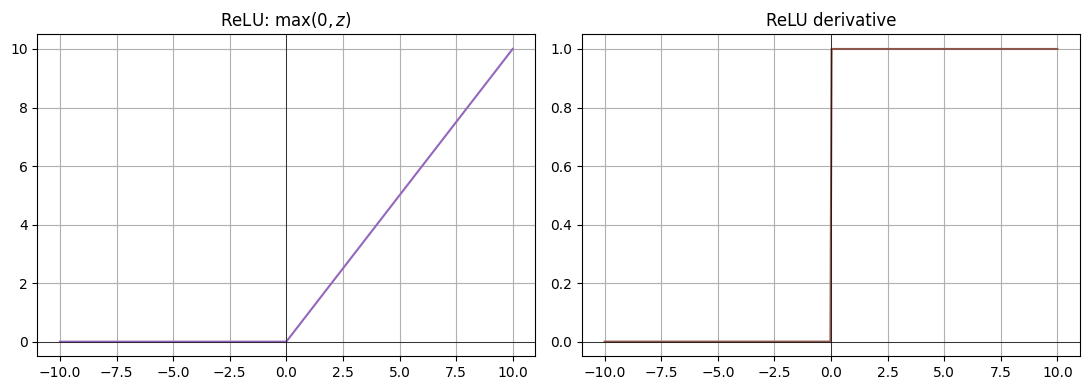

In [5]:
def relu(z):
    return np.maximum(0, z)

def relu_prime(z):
    return np.where(z > 0, 1, 0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, relu(z), color="tab:purple")
ax[0].set_title("ReLU: $\\max(0, z)$")
ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="k", lw=0.5)

ax[1].plot(z, relu_prime(z), color="tab:brown")
ax[1].set_title("ReLU derivative")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()


### ReLU vs Sigmoid

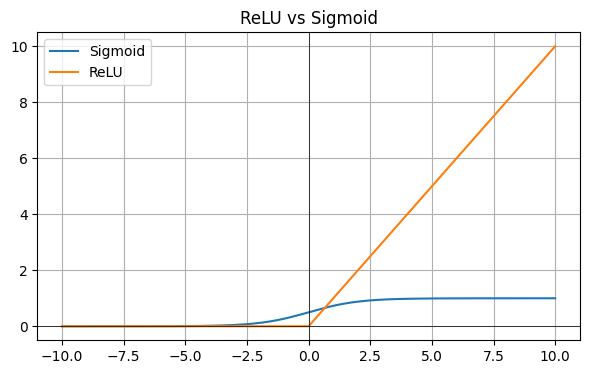

In [6]:
plt.plot(z, sigmoid(z), label="Sigmoid")
plt.plot(z, relu(z), label="ReLU")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.title("ReLU vs Sigmoid")
plt.legend()
plt.show()


## 4. Leaky ReLU

### Formula
$$
\text{LeakyReLU}(z) =
\begin{cases}
z, & z \ge 0 \\
\alpha z, & z < 0
\end{cases}
\qquad (\text{typically } \alpha = 0.01)
$$

### Derivative
$$
\text{LeakyReLU}'(z) =
\begin{cases}
1, & z > 0 \\
\alpha, & z < 0
\end{cases}
$$

### Mathematical properties
| Property | Value |
|---|---|
| Range | $(-\infty, \infty)$ |
| Domain | $(-\infty, \infty)$ |
| Monotonic | Yes |
| Zero-centered | Approximately (small negative slope, not exactly) |
| Differentiability | Not differentiable at $z=0$ (like ReLU) |
| Parametric variant | **Parametric ReLU (PReLU)** learns $\alpha$ as a trainable parameter instead of fixing it |

### Advantages
- **Fixes the dying-ReLU problem**: the small slope $\alpha$ for $z<0$ keeps the gradient non-zero, so neurons can keep learning even when their pre-activation is negative.
- Still very cheap to compute — essentially the same cost as ReLU.
- Retains ReLU's advantages (no vanishing-gradient on the positive side, simple form).

### Disadvantages
- Results are **not consistent** for negative inputs — the fixed slope $\alpha$ is a hyperparameter chosen ahead of time and may not be optimal for every problem.
- If the learning rate is set too high, weight updates can still overshoot and push a neuron into a poorly-performing state.
- Introduces an extra hyperparameter ($\alpha$) to tune (unless using the learned PReLU variant).


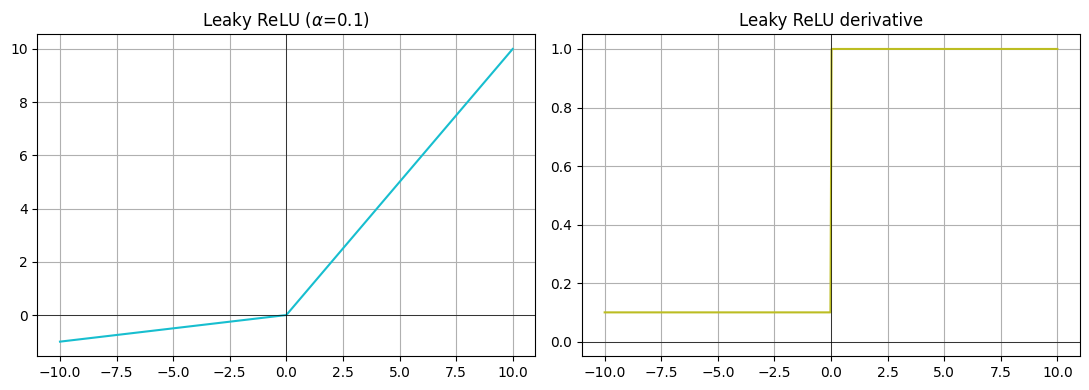

In [7]:
def leaky_relu(z, alpha=0.01):
    return np.where(z >= 0, z, alpha * z)

def leaky_relu_prime(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

alpha = 0.1  # exaggerated for visibility in the plot
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, leaky_relu(z, alpha), color="tab:cyan")
ax[0].set_title(f"Leaky ReLU ($\\alpha$={alpha})")
ax[0].axhline(0, color="k", lw=0.5); ax[0].axvline(0, color="k", lw=0.5)

ax[1].plot(z, leaky_relu_prime(z, alpha), color="tab:olive")
ax[1].set_title("Leaky ReLU derivative")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()


### Leaky ReLU vs ReLU

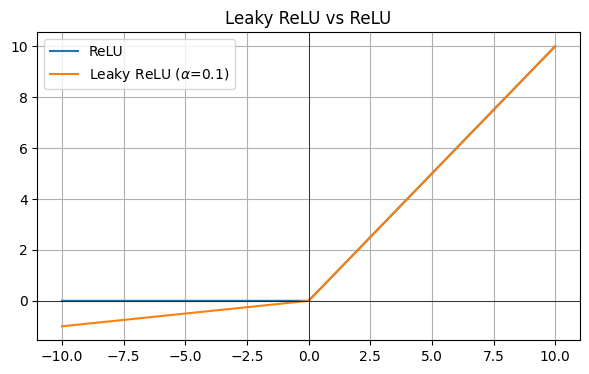

In [8]:
plt.plot(z, relu(z), label="ReLU")
plt.plot(z, leaky_relu(z, alpha=0.1), label="Leaky ReLU ($\\alpha$=0.1)")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.title("Leaky ReLU vs ReLU")
plt.legend()
plt.show()


## 5. Softmax

### Formula
For a vector $\mathbf{z} = (z_1, z_2, \dots, z_K)$:
$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}, \qquad i = 1, \dots, K
$$

### Derivative (Jacobian)
$$
\frac{\partial \,\text{softmax}(z_i)}{\partial z_j} =
\begin{cases}
\text{softmax}(z_i)\big(1 - \text{softmax}(z_i)\big), & i = j \\
-\,\text{softmax}(z_i)\,\text{softmax}(z_j), & i \ne j
\end{cases}
$$

### Mathematical properties
| Property | Value |
|---|---|
| Range | $(0, 1)$ for each component |
| Sum constraint | $\sum_{i=1}^{K} \text{softmax}(z_i) = 1$ (a valid probability distribution) |
| Interdependence | Outputs are **not independent** — increasing one component's probability necessarily decreases the others |
| Translation invariance | $\text{softmax}(\mathbf{z}) = \text{softmax}(\mathbf{z} + c)$ for any constant $c$ (used for numerical stability) |
| Generalization | Reduces to sigmoid when $K=2$ |

### Advantages
- Produces a genuine **probability distribution over multiple classes**, which is exactly what's needed for multi-class classification.
- Naturally generalizes sigmoid/logistic regression to more than two classes.
- Differentiable, so it plugs directly into gradient-based training (typically paired with cross-entropy loss).

### Disadvantages
- Not suited to hidden layers — it's designed for a network's **final/output layer** in classification.
- Because outputs are coupled (they must sum to 1), it can be sensitive to outlier logits — a single very large $z_i$ can dominate the whole distribution.
- Computing the exponentials/sum can be numerically unstable for large inputs without the max-subtraction trick.
- Assumes classes are **mutually exclusive**; not appropriate for multi-label problems.


In [9]:
def softmax(z):
    z = np.array(z, dtype=float)
    shifted = z - np.max(z)           # numerical-stability trick (translation invariance)
    exp_z = np.exp(shifted)
    return exp_z / np.sum(exp_z)

inputs = [-0.5, 1.2, -0.1, 2.4]

sig_out = sigmoid(np.array(inputs))
soft_out = softmax(inputs)

print("Inputs:               ", inputs)
print("Sigmoid outputs:      ", np.round(sig_out, 2), " -> sum =", round(sig_out.sum(), 2))
print("Softmax outputs:      ", np.round(soft_out, 2), " -> sum =", round(soft_out.sum(), 2))


Inputs:                [-0.5, 1.2, -0.1, 2.4]
Sigmoid outputs:       [0.38 0.77 0.48 0.92]  -> sum = 2.54
Softmax outputs:       [0.04 0.21 0.06 0.7 ]  -> sum = 1.0


Notice how the **sigmoid** treats each input independently (outputs don't sum to 1),
while **softmax** couples all four values into a single probability distribution that
sums to exactly 1 — increasing one class's probability forces the others down.

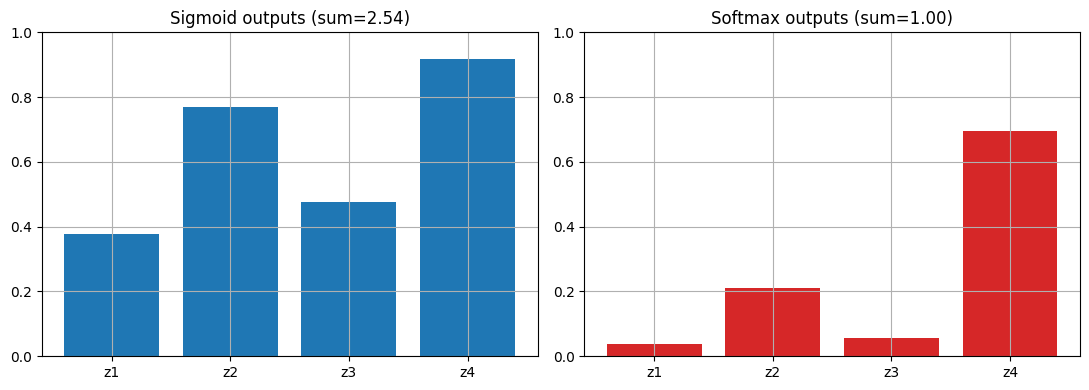

In [10]:
labels = ["z1", "z2", "z3", "z4"]
x_pos = np.arange(len(inputs))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(x_pos, sig_out, color="tab:blue")
ax[0].set_xticks(x_pos); ax[0].set_xticklabels(labels)
ax[0].set_title(f"Sigmoid outputs (sum={sig_out.sum():.2f})")
ax[0].set_ylim(0, 1)

ax[1].bar(x_pos, soft_out, color="tab:red")
ax[1].set_xticks(x_pos); ax[1].set_xticklabels(labels)
ax[1].set_title(f"Softmax outputs (sum={soft_out.sum():.2f})")
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## All Activation Functions — Side by Side

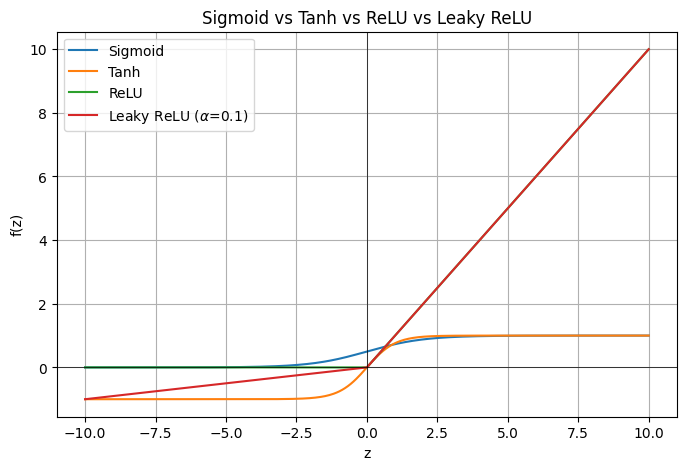

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, sigmoid(z), label="Sigmoid")
ax.plot(z, tanh(z), label="Tanh")
ax.plot(z, relu(z), label="ReLU")
ax.plot(z, leaky_relu(z, alpha=0.1), label="Leaky ReLU ($\\alpha$=0.1)")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title("Sigmoid vs Tanh vs ReLU vs Leaky ReLU")
ax.set_xlabel("z"); ax.set_ylabel("f(z)")
ax.legend()
plt.show()


## Summary Table

| Function | Formula | Range | Zero-centered | Vanishing gradient | Typical use |
|---|---|---|---|---|---|
| **Sigmoid** | $1/(1+e^{-z})$ | $(0,1)$ | No | Yes (both tails) | Binary classification output |
| **Tanh** | $\dfrac{e^{z}-e^{-z}}{e^{z}+e^{-z}}$ | $(-1,1)$ | Yes | Yes (both tails) | RNNs, hidden layers (older nets) |
| **ReLU** | $\max(0,z)$ | $[0,\infty)$ | No | No (for $z>0$); dying neurons for $z<0$ | Default for hidden layers |
| **Leaky ReLU** | $z$ if $z\ge0$ else $\alpha z$ | $(-\infty,\infty)$ | Approx. | No | Hidden layers, fixes dying ReLU |
| **Softmax** | $e^{z_i}/\sum_j e^{z_j}$ | $(0,1)$, sums to 1 | No | N/A (output layer) | Multi-class classification output |

### Practical takeaway
As a general rule of thumb: use **ReLU (or a variant like Leaky ReLU)** in hidden layers
for better gradient flow and computational efficiency, and reserve **Sigmoid** for binary
output and **Softmax** for multi-class output layers. The right choice ultimately still
depends on the specific architecture and problem at hand.

### References
- Mukesh Chaudhary, *"Activation Functions: Sigmoid, Tanh, ReLU, Leaky ReLU, Softmax"* — [Medium article](https://medium.com/@cmukesh8688/activation-functions-sigmoid-tanh-relu-leaky-relu-softmax-50d3778dcea5)
- [Keras activation layers documentation](https://keras.io/api/layers/activations/)
- [Wikipedia: Activation function](https://en.wikipedia.org/wiki/Activation_function)
